# Spotify Taste Analysis: Part 2

Sections in this notebook:

1. Audio Feature Correlation Matrix
2. Mood Quadrant: Valence vs Energy
3. Energy vs Acousticness
4. Genre vs Audio Feature Heatmap
5. Top Albums by Track Count
6. Artist Audio Fingerprints
7. Taste Frontier: t-SNE and One-Class SVM
8. Taste Frontier: PCA and One-Class SVM

Ensure `all_my_music_cleaned.csv` is in the same directory before running.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [3]:
df = pd.read_csv('all_my_music_cleaned.csv')
df['Release Date'] = pd.to_datetime(df['Release Date'], format='mixed')
df['Release Year'] = df['Release Date'].dt.year
df.shape

(581, 25)

## 1. Audio Feature Correlation Matrix

This heatmap shows the Pearson correlation coefficient between every pair of Spotify audio features. Values close to 1 indicate a strong positive relationship; close to -1 means the opposite; near 0 means little to no linear relationship. Only the lower triangle is shown to avoid duplication.

A diverging colour palette is used here because values span from -1 to +1. A sequential palette would flatten the distinction between positive and negative correlations.

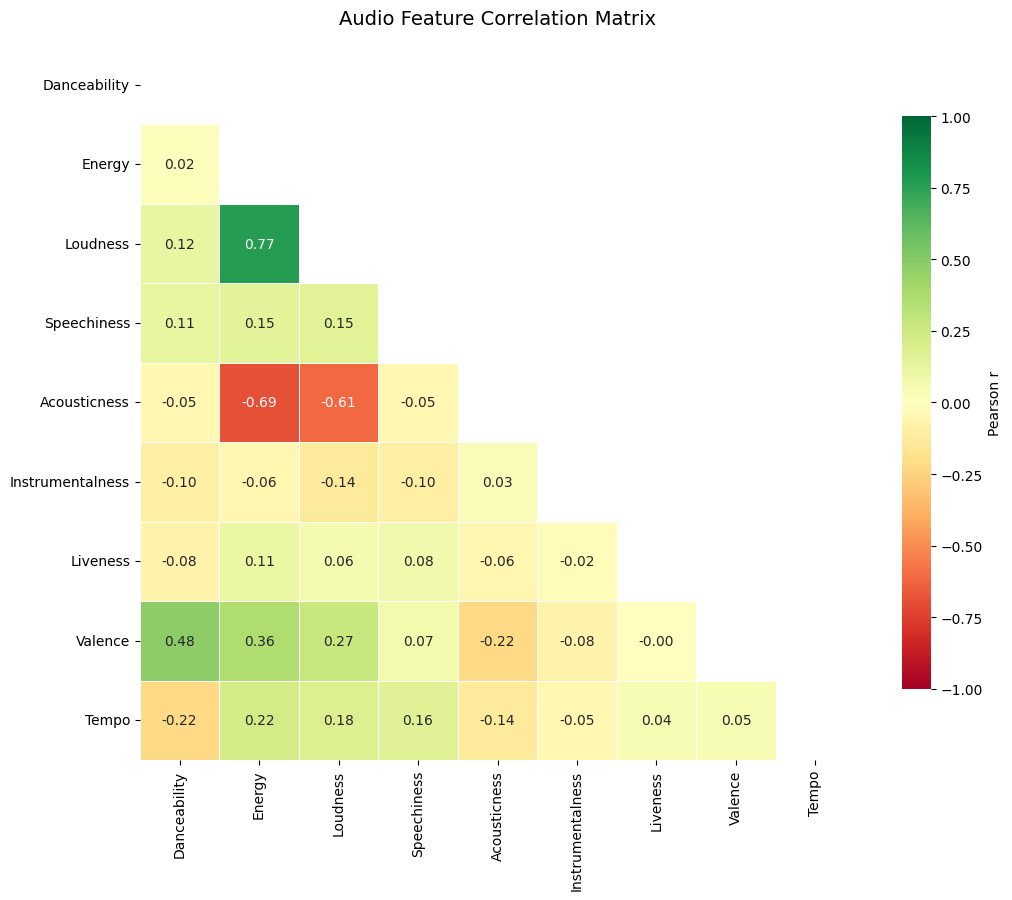

In [4]:
audio_features = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo'
]

corr = df[audio_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)
plt.title('Audio Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 2. Mood Quadrant: Valence vs Energy

Valence (positivity) and Energy are arguably the two most interpretable audio features Spotify provides. Plotting each track in this two-dimensional space creates a rough emotional map of the library. The four quadrants correspond to four broad moods:

| | High Energy | Low Energy |
|---|---|---|
| **High Valence** | Happy and Energetic | Happy and Calm |
| **Low Valence** | Tense and Angry | Sad and Melancholic |

Points are coloured by Spotify popularity score.

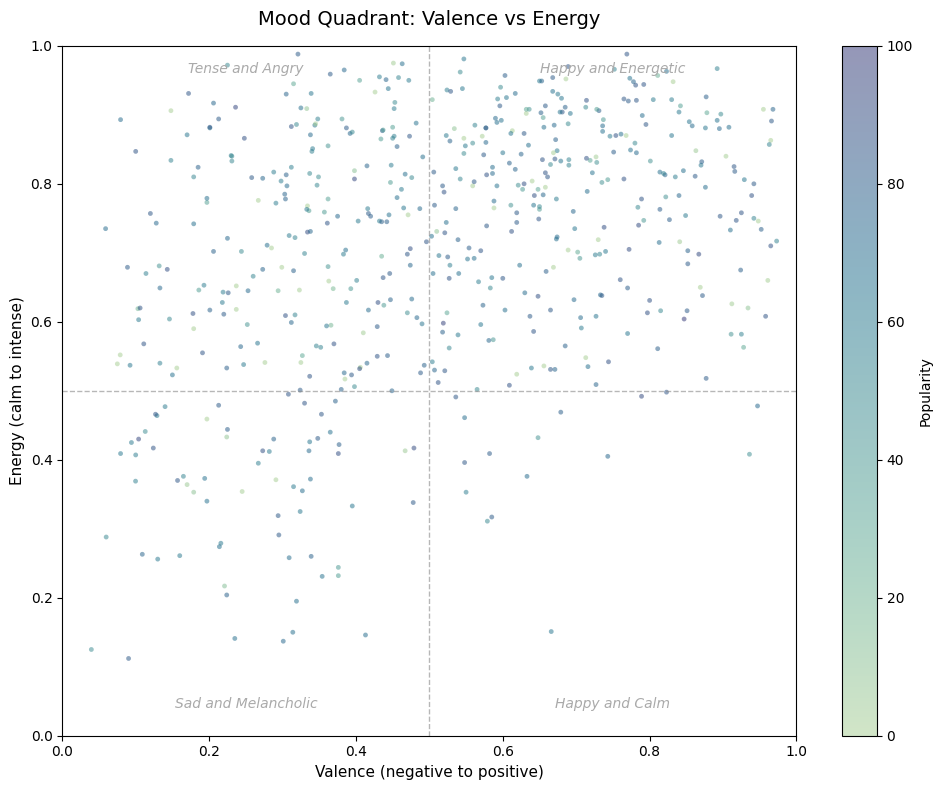

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    df['Valence'], df['Energy'],
    c=df['Popularity'], cmap='crest',
    alpha=0.5, s=12, edgecolors='none'
)

ax.axvline(x=0.5, color='#888888', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=0.5, color='#888888', linestyle='--', linewidth=1, alpha=0.6)

label_kw = dict(fontsize=10, color='#aaaaaa', style='italic',
                ha='center', transform=ax.transAxes)
ax.text(0.75, 0.96, 'Happy and Energetic', **label_kw)
ax.text(0.75, 0.04, 'Happy and Calm',      **label_kw)
ax.text(0.25, 0.96, 'Tense and Angry',     **label_kw)
ax.text(0.25, 0.04, 'Sad and Melancholic', **label_kw)

plt.colorbar(scatter, ax=ax, label='Popularity')
ax.set_xlabel('Valence (negative to positive)', fontsize=11)
ax.set_ylabel('Energy (calm to intense)', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Mood Quadrant: Valence vs Energy', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 3. Energy vs Acousticness

Energy and Acousticness tend to pull in opposite directions: acoustic recordings typically feel less intense, while heavily produced or electronic tracks tend to register as more energetic. This scatter plots the library along a rough organic vs electronic axis, with KDE contour lines showing where the density of tracks is highest. Points are coloured by Valence, revealing whether the acoustic corner is also the sadder corner and whether the electronic corner skews happier.

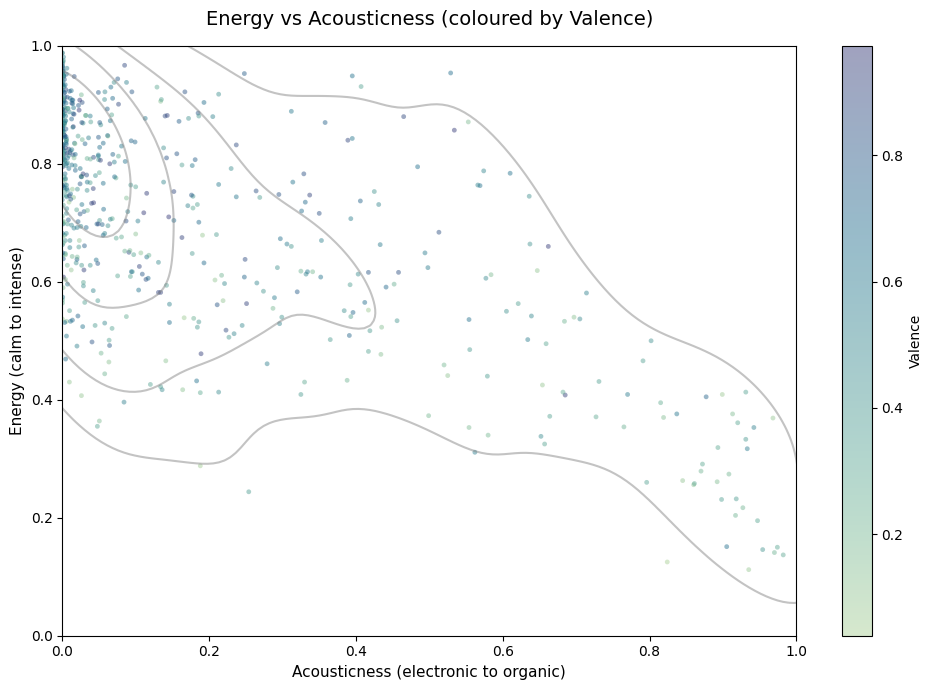

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.kdeplot(data=df, x='Acousticness', y='Energy',
            color='#888888', alpha=0.5, levels=5, ax=ax)

scatter = ax.scatter(
    df['Acousticness'], df['Energy'],
    c=df['Valence'], cmap='crest',
    alpha=0.45, s=12, edgecolors='none'
)

plt.colorbar(scatter, ax=ax, label='Valence')
ax.set_xlabel('Acousticness (electronic to organic)', fontsize=11)
ax.set_ylabel('Energy (calm to intense)', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Energy vs Acousticness (coloured by Valence)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 4. Genre vs Audio Feature

This heatmap shows the mean audio feature values for each of the top 15 genres in the library. To make features comparable despite their different scales (Tempo runs 60 to 200 BPM while most others sit between 0 and 1), all values are column-normalised to a 0 to 1 range within each feature. A cell close to 1 means that genre scores near the top of its range relative to the others shown; a cell close to 0 means near the bottom. Only tracks with genre data available are included here.

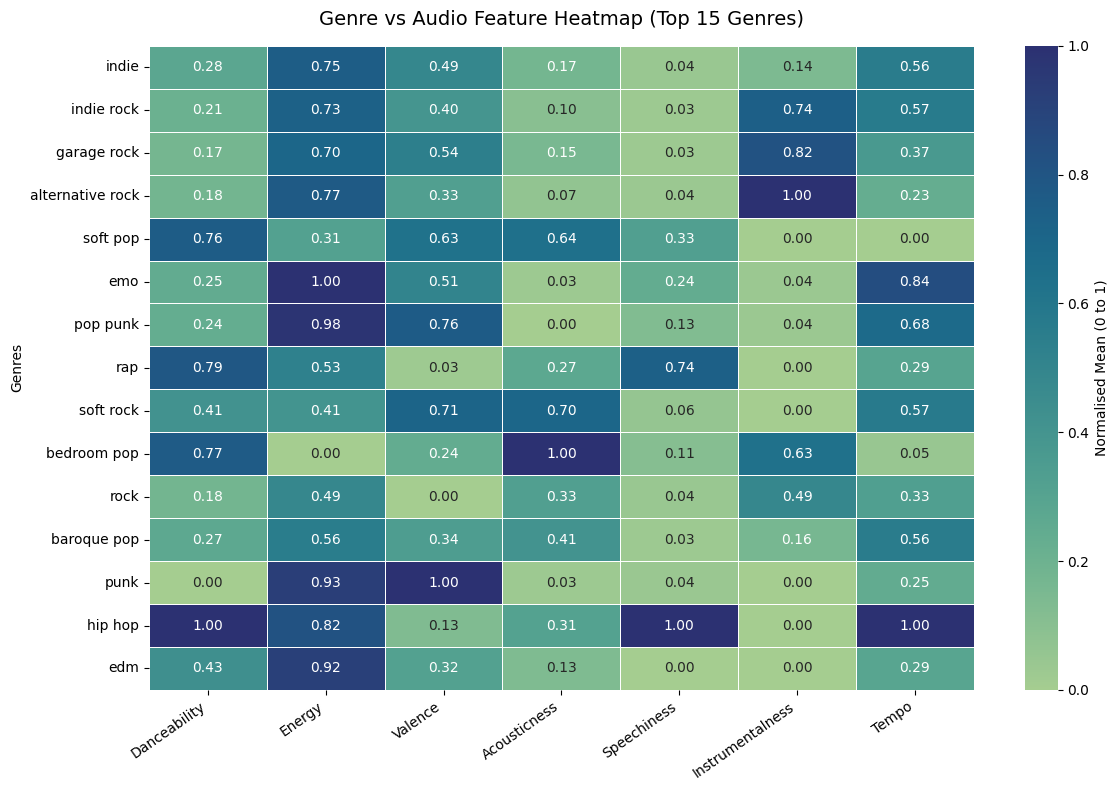

In [8]:
heatmap_features = [
    'Danceability', 'Energy', 'Valence',
    'Acousticness', 'Speechiness', 'Instrumentalness', 'Tempo'
]

top_genre_n = 15
genre_series    = df['Genres'].dropna().str.split(',').explode().str.strip()
top_genres_list = genre_series.value_counts().head(top_genre_n).index.tolist()

df_g = df[heatmap_features + ['Genres']].copy()
df_g = df_g.dropna(subset=['Genres'])
df_g['Genres'] = df_g['Genres'].str.split(',')
df_g = df_g.explode('Genres')
df_g['Genres'] = df_g['Genres'].str.strip()
df_g = df_g[df_g['Genres'].isin(top_genres_list)]

genre_means = df_g.groupby('Genres')[heatmap_features].mean()
genre_means = genre_means.reindex(top_genres_list).dropna()
genre_norm  = (genre_means - genre_means.min()) / (genre_means.max() - genre_means.min())

plt.figure(figsize=(12, 8))
sns.heatmap(
    genre_norm, annot=True, fmt='.2f', cmap='crest',
    linewidths=0.5, cbar_kws={'label': 'Normalised Mean (0 to 1)'}
)
plt.title(f'Genre vs Audio Feature Heatmap (Top {top_genre_n} Genres)', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 5. Top Albums by Track Count

This chart counts how many tracks from each album appear in the library. A high count for a single album suggests the full album was added deliberately; lower counts spread across many albums points to individual track curation. Compilation and greatest hits albums can appear with high counts despite not representing a single cohesive body of work.

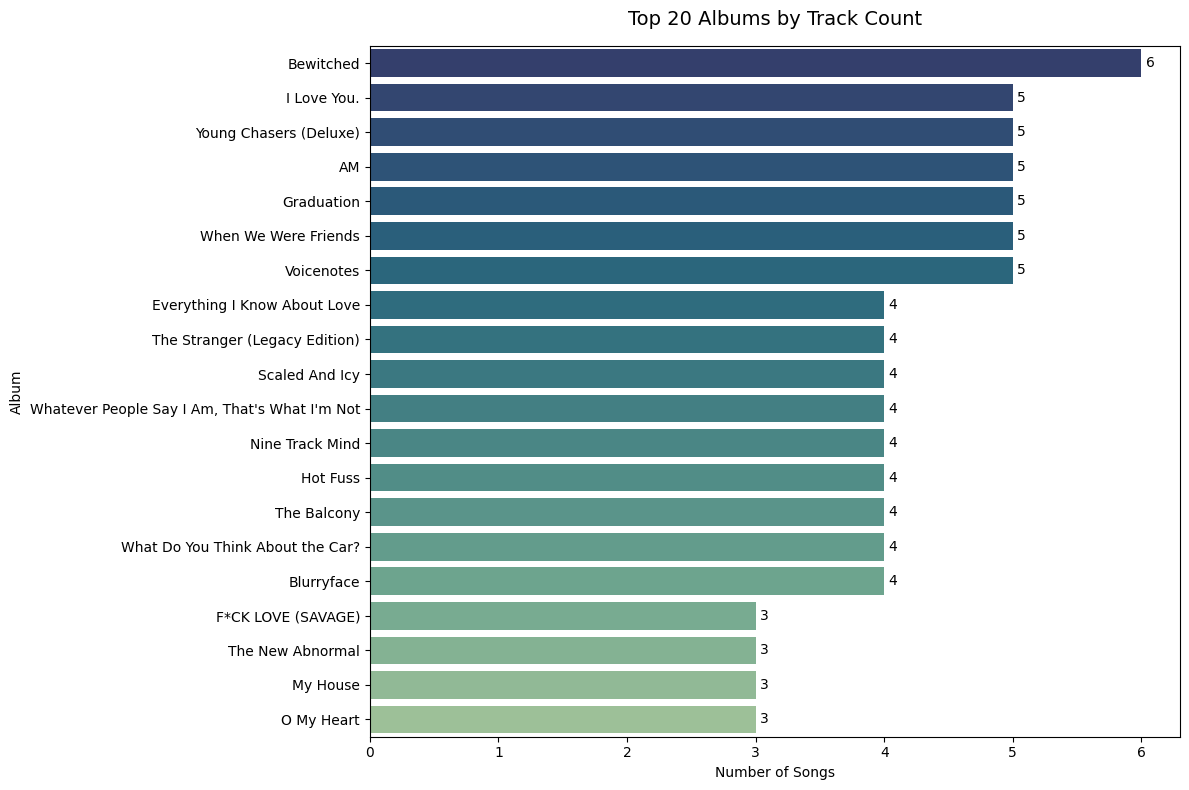

In [9]:
top_album_n = 20

album_counts = (df.groupby('Album Name')['Track Name']
                .count()
                .sort_values(ascending=False)
                .head(top_album_n))

plt.figure(figsize=(12, 8))
sns.barplot(x=album_counts.values, y=album_counts.index,
            hue=album_counts.index, palette='crest_r', legend=False)
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title(f'Top {top_album_n} Albums by Track Count', fontsize=14, pad=15)
plt.xlabel('Number of Songs')
plt.ylabel('Album')
plt.tight_layout()
plt.show()

## 6. Artist Audio Fingerprints

Each of the top 5 artists is shown as its own radar chart, with their mean audio feature scores plotted as a coloured polygon. The grey dashed polygon on each chart shows the library average across all tracks, making it easy to see where an artist sits above or below the norm. All features are on a 0 to 1 scale. Each artist's profile reflects only the tracks present in this library, which may be a small and potentially unrepresentative sample.

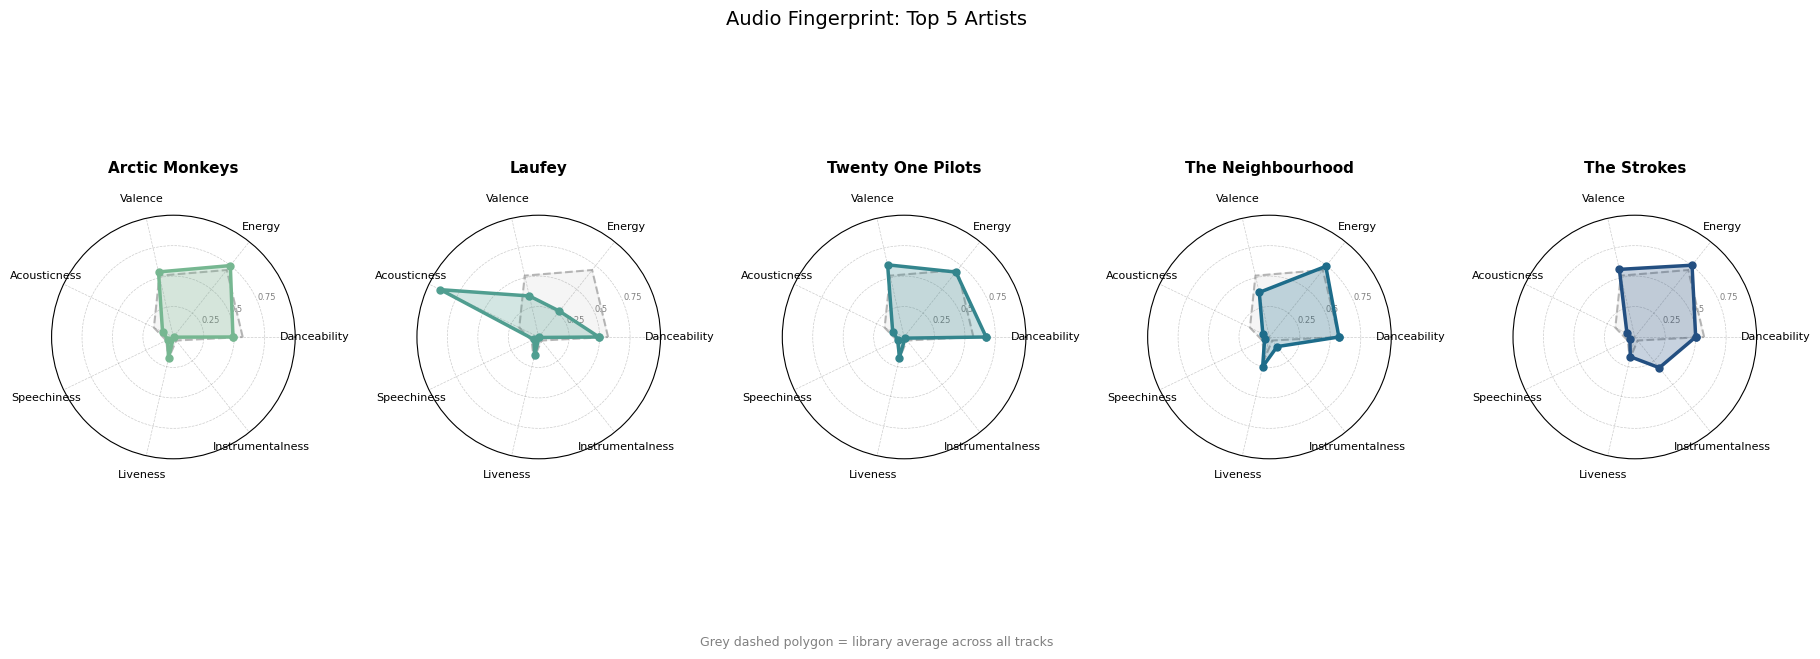

In [10]:
radar_features = [
    'Danceability', 'Energy', 'Valence',
    'Acousticness', 'Speechiness', 'Liveness', 'Instrumentalness'
]

top_artist_n     = 5
top_artists_list = df['Artist Name(s)'].value_counts().head(top_artist_n).index.tolist()
colours          = sns.color_palette('crest', top_artist_n)

N      = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

lib_mean  = df[radar_features].mean().tolist()
lib_mean += lib_mean[:1]

fig, axes = plt.subplots(1, top_artist_n, figsize=(22, 6),
                          subplot_kw=dict(polar=True))
plt.subplots_adjust(wspace=0.5)

for idx, (artist, ax) in enumerate(zip(top_artists_list, axes)):
    values  = df[df['Artist Name(s)'] == artist][radar_features].mean().tolist()
    values += values[:1]

    ax.plot(angles, lib_mean, color='#bbbbbb', linewidth=1.5,
            linestyle='--', zorder=1)
    ax.fill(angles, lib_mean, alpha=0.08, color='grey', zorder=1)

    ax.plot(angles, values, 'o-', linewidth=2.5, color=colours[idx],
            markersize=5, zorder=2)
    ax.fill(angles, values, alpha=0.25, color=colours[idx], zorder=2)

    ax.set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.5', '0.75'], fontsize=6, color='grey')
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.4)
    ax.set_title(artist, fontsize=11, pad=15, fontweight='bold')

fig.text(0.5, -0.02,
         'Grey dashed polygon = library average across all tracks',
         ha='center', fontsize=9, color='grey')
plt.suptitle('Audio Fingerprint: Top 5 Artists', fontsize=14, y=1.04)
plt.show()

## 7. Taste Frontier: t-SNE and One-Class SVM

This section uses two techniques together to map the shape of musical taste:

**t-SNE** (t-distributed Stochastic Neighbour Embedding) reduces the full set of audio features to two dimensions, attempting to preserve the pairwise similarities between songs. Songs that are sonically similar end up near each other in the 2D space.

A **One-Class SVM** is then trained on the 2D embedding. It learns a decision boundary that encloses the majority of songs (the "core taste") and marks the rest as statistical outliers. The `nu` parameter controls what fraction of tracks are allowed to fall outside the boundary; 0.1 means at most 10% are treated as outliers.

Points are coloured by their SVM score: positive (green) means inside the taste boundary, negative (red) means outside it. Songs labelled in dark green are the most "central" to the taste; songs labelled in dark red are the most atypical.

Note that t-SNE is stochastic. The random seed is fixed here for reproducibility, but changing it will produce a different spatial layout with the same underlying structure.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

num_features = [
    'Duration (ms)', 'Popularity', 'Danceability', 'Energy', 'Key',
    'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness',
    'Liveness', 'Valence', 'Tempo', 'Time Signature'
]

df_svm = df.copy()
df_svm['Release Year Num'] = df_svm['Release Year'].fillna(df_svm['Release Year'].median())
all_feat = num_features + ['Release Year Num']

df_svm = (df_svm[all_feat + ['Track Name', 'Artist Name(s)']]
          .dropna(subset=num_features)
          .reset_index(drop=True))
X_scaled = StandardScaler().fit_transform(df_svm[all_feat].values)

print(f"Songs in embedding: {len(X_scaled)}")
print(f"Features used: {all_feat}")

Songs in embedding: 581
Features used: ['Duration (ms)', 'Popularity', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Time Signature', 'Release Year Num']


In [18]:
def plot_taste_frontier(X_2d, df_ref, technique_name, nu=0.1,
                        n_central=12, n_outlier=5):
    svm = OneClassSVM(gamma='scale', nu=nu)
    svm.fit(X_2d)
    scores = svm.decision_function(X_2d)

    pad = abs(X_2d).max() * 0.13
    x_min, x_max = X_2d[:, 0].min() - pad, X_2d[:, 0].max() + pad
    y_min, y_max = X_2d[:, 1].min() - pad, X_2d[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                          np.linspace(y_min, y_max, 500))
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(13, 11))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#f7fbff')

    # Outside gradient
    ax.contourf(xx, yy, Z,
                 levels=np.linspace(min(Z.min(), -0.001), 0, 8),
                 cmap='Blues_r', alpha=0.55)
    # Inside fill
    ax.contourf(xx, yy, Z,
                 levels=[0, max(Z.max(), 0.001)],
                 colors=['#d4ede8'], alpha=0.95)
    # Boundary
    ax.contour(xx, yy, Z, levels=[0],
                colors=['#00765B'], linewidths=2.5)

    # Points coloured by SVM score, symmetric around 0
    norm = TwoSlopeNorm(
        vmin=scores.min(), vcenter=0,
        vmax=max(scores.max(), abs(scores.min()) * 0.1)
    )
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                     c=scores, cmap='RdYlGn', norm=norm,
                     s=20, alpha=0.7, edgecolors='none', zorder=5)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.02)
    cbar.set_label('SVM score (positive = inside taste boundary)', fontsize=9)

    # Annotation helpers
    cx = np.median(X_2d[:, 0])
    cy = np.median(X_2d[:, 1])

    def annotate_song(idx, colour, arrow_colour, outward=True):
        name = str(df_ref.iloc[idx]['Track Name'])[:32]
        x, y = X_2d[idx]
        angle = np.arctan2(y - cy, x - cx)
        dist = 60 if outward else -50
        tx = np.cos(angle) * dist
        ty = np.sin(angle) * dist
        ax.annotate(
            name, xy=(x, y), xytext=(tx, ty),
            textcoords='offset points',
            fontsize=7.5, color=colour, fontweight='bold',
            ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color=arrow_colour, lw=0.8),
            bbox=dict(boxstyle='round,pad=0.25', fc='white',
                      alpha=0.8, ec='none'),
            zorder=10
        )

    for idx in np.argsort(scores)[-n_central:][::-1]:
        annotate_song(idx, '#004d3a', '#00765B', outward=True)

    for idx in np.argsort(scores)[:n_outlier]:
        annotate_song(idx, '#7a1c1c', '#cc3333', outward=True)

    ax.set_title(
        f'Taste Frontier: {technique_name} + One-Class SVM'
        f'Teal region = core taste  |  blue gradient = increasingly atypical',
        fontsize=13, pad=12
    )
    ax.set_xlabel(f'{technique_name} Dimension 1', fontsize=10)
    ax.set_ylabel(f'{technique_name} Dimension 2', fontsize=10)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    plt.tight_layout()
    plt.show()
    return scores

t-SNE embedding complete


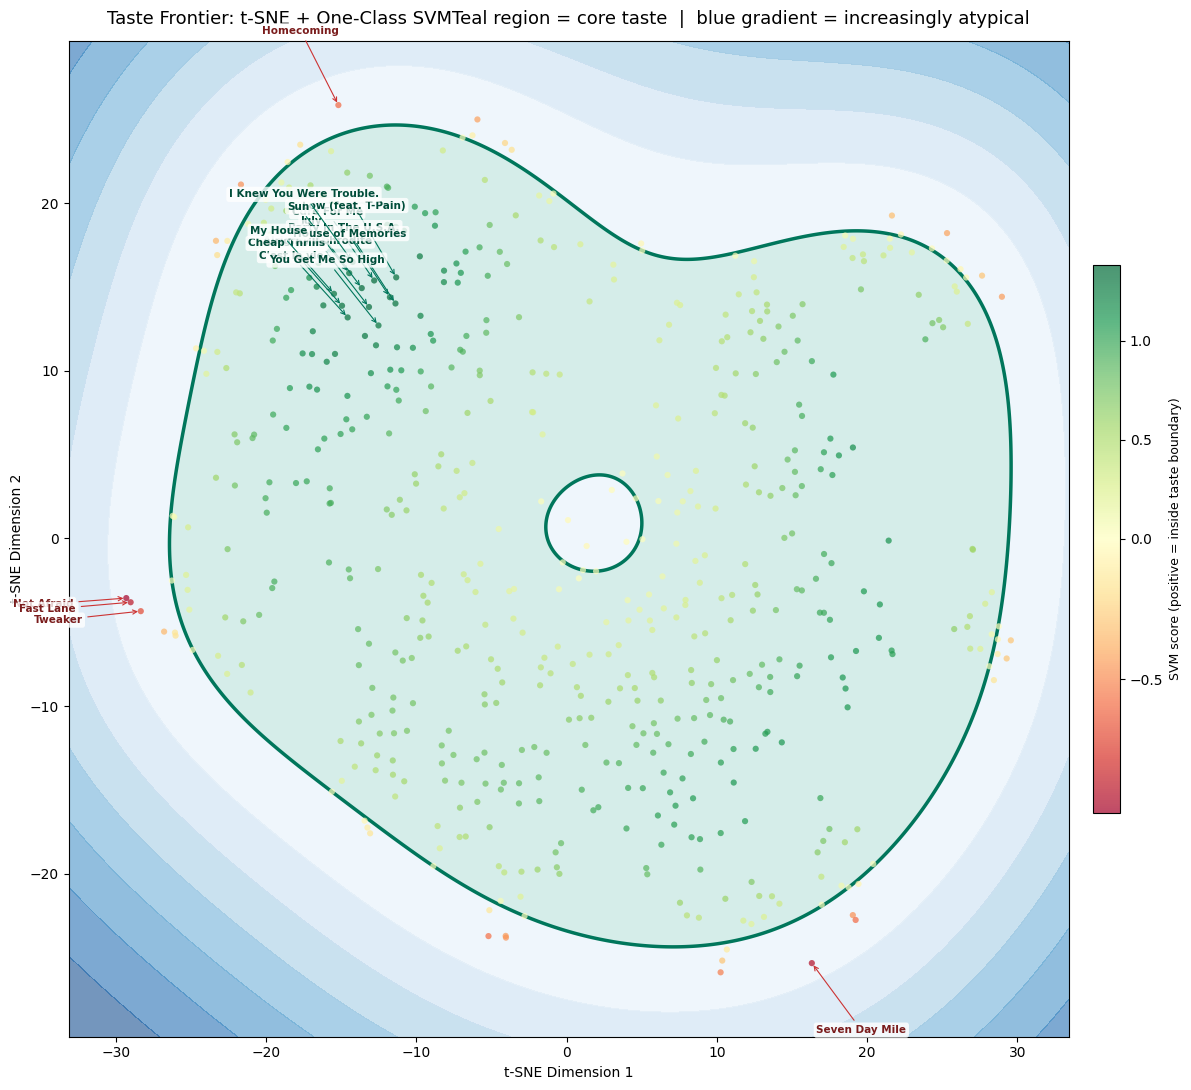

In [24]:
from sklearn.manifold import TSNE

np.random.seed(42)
X_tsne = TSNE(n_components=2, random_state=42,
    perplexity=30, max_iter=1000).fit_transform(X_scaled)
print("t-SNE embedding complete")
scores_tsne = plot_taste_frontier(X_tsne, df_svm, 't-SNE')

## 8. Taste Frontier: PCA and One-Class SVM

Principal Component Analysis (PCA) is a deterministic alternative to t-SNE. Rather than trying to preserve pairwise distances between all songs, PCA finds the two directions in the original feature space that explain the most variance across the dataset. The result is always the same for a given dataset, unlike t-SNE.

The trade-off is that PCA often produces a more elongated, less visually dramatic layout, and it can only capture linear structure in the data. The variance explained by each component is printed below, giving a sense of how much information is retained in the 2D projection.

Variance explained by PC1: 19.0%
Variance explained by PC2: 11.1%
Total: 30.1%


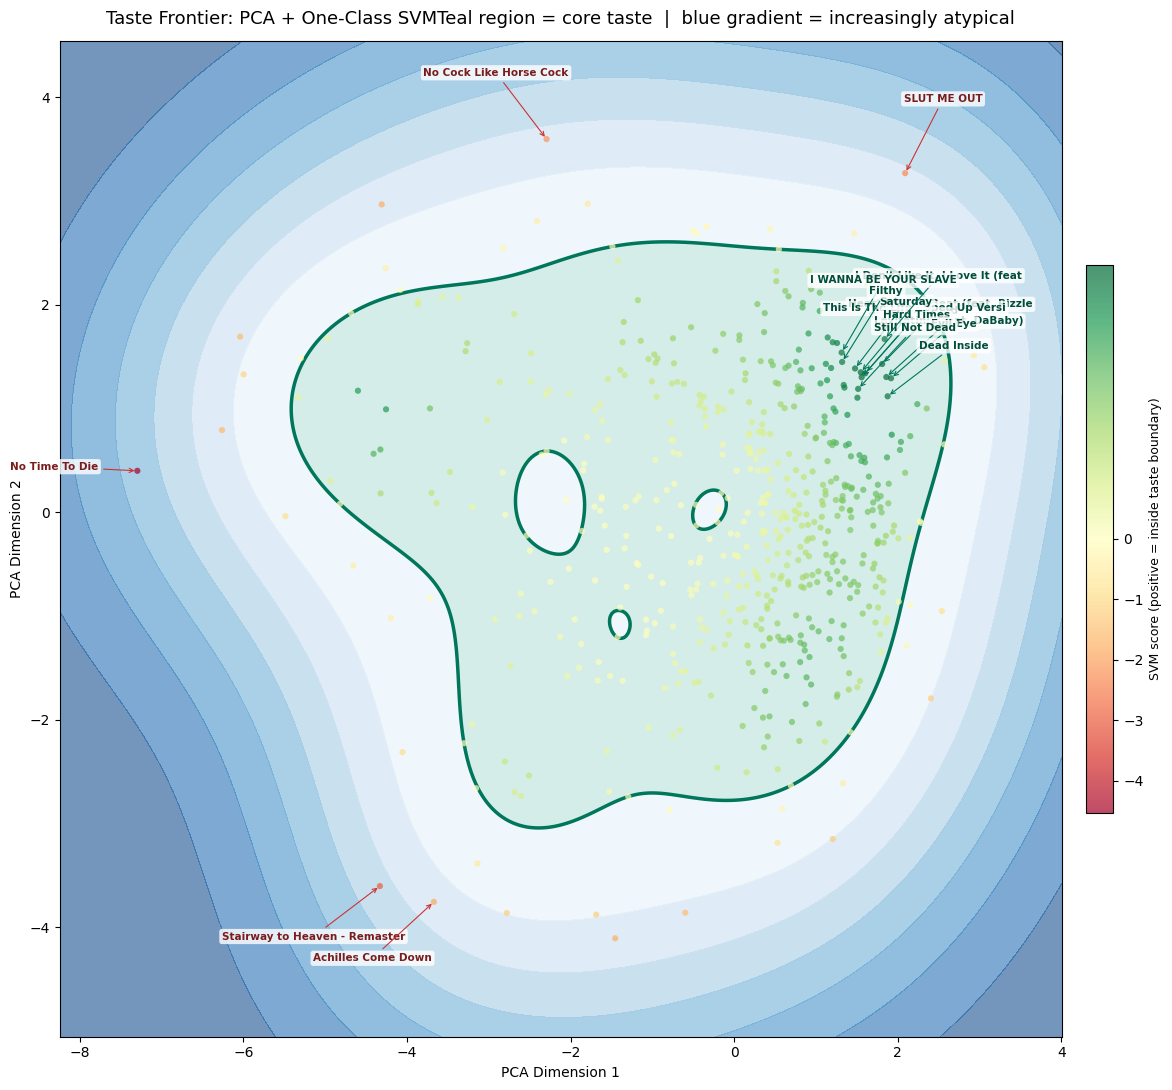

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total: {pca.explained_variance_ratio_.sum():.1%}")
scores_pca = plot_taste_frontier(X_pca, df_svm, 'PCA')